# **📝 Guión del Laboratorio: "Análisis de Salud con NumPy"**

El gancho inicial: Muestra el error del nan en los primeros 30 segundos y diles: "Hoy aprenderás a dominar NumPy para limpiar esto por completo sin usar Pandas".

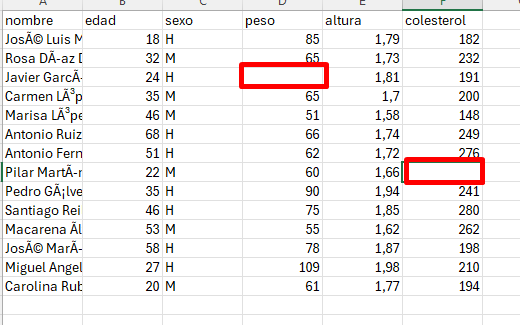.

# **RETO :**

Imagina que recibimos un archivo llamado Colesterol.csv con datos de salud de 5 personas. El archivo contiene:

Columna 0: Nombre

Columna 1: Edad (Años).

Columna 2: Sexo

Columna 3: Peso

Columna 4: Altura

Columna 5: Colesterol.

**🛠️ Paso 1: Configuración e Importación (Manejo de strings y nulos)**

In [27]:
import numpy as np

# Approach B: Read everything as string, then use np.char.replace
data_str = np.genfromtxt('/content/sample_data/Colesterol.csv', delimiter=';', skip_header=1, usecols=(1, 3, 4, 5), dtype=str)
print("Datos originales:")
print(data_str[:5])




Datos originales:
[['18' '85' '1,79' '182']
 ['32' '65' '1,73' '232']
 ['24' '' '1,81' '191']
 ['35' '65' '1,70' '200']
 ['46' '51' '1,58' '148']]


**🔍 Paso 2: Inspección y Estructura**

In [28]:
filas, columnas = data_str.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")
print(f"Tipo de datos inicial: {data_str.dtype}")

El dataset tiene 14 filas y 4 columnas.
Tipo de datos inicial: <U4


 **🧽 Paso 3: Filtrado, Limpieza y Detección de Nulos**

In [37]:
# Uso de .astype() -> Lo convertimos a float32 para optimizar memoria
# Replace commas with dots
data_str = np.char.replace(data_str, ',', '.')

# Replace empty strings with 'nan' so astype(float) works
data_str = np.where(data_str == '', 'nan', data_str)

# Convert to float
data_float = data_str.astype(float)
print("\nConverted float data:")
print(data_float[:5])
print(f"Tipo de datos inicial: {data_float.dtype}")


Converted float data:
[[ 18.    85.     1.79 182.  ]
 [ 32.    65.     1.73 232.  ]
 [ 24.      nan   1.81 191.  ]
 [ 35.    65.     1.7  200.  ]
 [ 46.    51.     1.58 148.  ]]
Tipo de datos inicial: float64


Pausa activa: En el Paso 3, diles que pausen el video e intenten cambiar **el 0 de np.where() por la media de la columna**. Eso aumentará el tiempo de retención del video.

In [41]:
# Uso de np.where() -> Reemplazar los 'nan' de colesterol y presión por 0 (o la media)
# Si es nulo pone 0, si no, mantiene el valor original
dataset_limpio = np.where(np.isnan(data_float), 0, data_float)

print("Dataset limpio (sin nulos):")
print(dataset_limpio)

##### PROPUESTA   PAUSAR EL VIDEO   ########

medias_columnas = np.round(np.nanmean(data_float, axis=0),2)

# 2. Reemplazamos: si es NaN, toma la media de su columna; si no, se queda igual
# NumPy mapea automáticamente cada columna con su media correspondiente (Broadcasting)
dataset_limpio = np.where(np.isnan(data_float), medias_columnas, data_float)

print("Dataset limpio (valores NaN reemplazados por la media de su columna):")
print(dataset_limpio)

Dataset limpio (sin nulos):
[[ 18.    85.     1.79 182.  ]
 [ 32.    65.     1.73 232.  ]
 [ 24.     0.     1.81 191.  ]
 [ 35.    65.     1.7  200.  ]
 [ 46.    51.     1.58 148.  ]
 [ 68.    66.     1.74 249.  ]
 [ 51.    62.     1.72 276.  ]
 [ 22.    60.     1.66   0.  ]
 [ 35.    90.     1.94 241.  ]
 [ 46.    75.     1.85 280.  ]
 [ 53.    55.     1.62 262.  ]
 [ 58.    78.     1.87 198.  ]
 [ 27.   109.     1.98 210.  ]
 [ 20.    61.     1.77 194.  ]]
Dataset limpio (valores NaN reemplazados por la media de su columna):
[[ 18.    85.     1.79 182.  ]
 [ 32.    65.     1.73 232.  ]
 [ 24.    70.92   1.81 191.  ]
 [ 35.    65.     1.7  200.  ]
 [ 46.    51.     1.58 148.  ]
 [ 68.    66.     1.74 249.  ]
 [ 51.    62.     1.72 276.  ]
 [ 22.    60.     1.66 220.23]
 [ 35.    90.     1.94 241.  ]
 [ 46.    75.     1.85 280.  ]
 [ 53.    55.     1.62 262.  ]
 [ 58.    78.     1.87 198.  ]
 [ 27.   109.     1.98 210.  ]
 [ 20.    61.     1.77 194.  ]]


**📊 Paso 4: Estadísticas por Variables (Eje axis=0)**

In [44]:
# np.mean, np.median, np.std, np.max, np.percentile
# Extraemos solo la columna de Colesterol (Índice 2)
colesterol = dataset_limpio[:, 2]

print(f"Media de colesterol: {np.mean(colesterol):.2f}")
print(f"Mediana de colesterol: {np.median(colesterol)}")
print(f"Desviación estándar: {np.std(colesterol):.2f}")
print(f"Valor máximo registrado: {np.max(colesterol)}")

# Detectar el percentil 90 para pacientes en riesgo
p90 = np.percentile(colesterol, 90)
print(f"El 90% de los pacientes tienen un colesterol menor a: {p90}\n")

Media de colesterol: 1.77
Mediana de colesterol: 1.755
Desviación estándar: 0.11
Valor máximo registrado: 1.98
El 90% de los pacientes tienen un colesterol menor a: 1.919



**📐 Paso 5: Manipulación de la Matriz**

Vamos a expandir nuestro dataset agregando registros (filas) y nuevas variables (columnas).

In [45]:
import numpy as np

# --- Asumiendo que vienes de los pasos anteriores ---
# dataset_limpio tiene 14 filas (del archivo Colesterol.csv)
# 1. Agregar un nuevo paciente (Fila) usando np.vstack()
nuevo_paciente = np.array([25, 70, 1.75, 210]) # Ajustado a la estructura (Edad, Peso, Altura, Colesterol)
dataset_ampliado = np.vstack((dataset_limpio, nuevo_paciente)) # Ahora tiene 15 filas

columna_riesgo = np.array([1, 2, 1, 3, 1, 2, 3, 1, 2, 1, 3, 2, 1, 2, 3]).reshape(-1, 1)

# 2. Agregar la columna de diagnóstico usando np.hstack()
# Como ambos tienen 15 filas, ahora encajarán a la perfección de forma horizontal
dataset_final = np.hstack((dataset_ampliado, columna_riesgo))

print("Dataset listo para guardar (con columna de riesgo al final):")
print(dataset_final)



Dataset listo para guardar (con columna de riesgo al final):
[[ 18.    85.     1.79 182.     1.  ]
 [ 32.    65.     1.73 232.     2.  ]
 [ 24.    70.92   1.81 191.     1.  ]
 [ 35.    65.     1.7  200.     3.  ]
 [ 46.    51.     1.58 148.     1.  ]
 [ 68.    66.     1.74 249.     2.  ]
 [ 51.    62.     1.72 276.     3.  ]
 [ 22.    60.     1.66 220.23   1.  ]
 [ 35.    90.     1.94 241.     2.  ]
 [ 46.    75.     1.85 280.     1.  ]
 [ 53.    55.     1.62 262.     3.  ]
 [ 58.    78.     1.87 198.     2.  ]
 [ 27.   109.     1.98 210.     1.  ]
 [ 20.    61.     1.77 194.     2.  ]
 [ 25.    70.     1.75 210.     3.  ]]


**💾 Paso 6: Exportación de Resultados**

In [46]:
# Guardamos el resultado final en un nuevo archivo CSV formateado con np.savetxt()
# '%.2f' guarda los números con dos decimales para que sea legible
np.savetxt('reporte_pacientes_limpio.csv', dataset_final, delimiter=',', fmt='%.2f')
print("\n¡Archivo 'reporte_pacientes_limpio.csv' exportado con éxito!")


¡Archivo 'reporte_pacientes_limpio.csv' exportado con éxito!
